# LSTM Neural Network for Affordability Metric

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
df = pd.read_csv('../data/processed/final_3d_df_REVISED.csv')

In [3]:
lag_features = [col for col in df.columns if 'prev_mo' in col]
feature_columns = lag_features
fips_encoded = pd.get_dummies(df['fips'], prefix='fips', drop_first=True)

X_feature = df[feature_columns].values
X = np.column_stack([X_feature, fips_encoded.values])
y = df['Affordability Metric'].values

In [4]:
# fix data leakage
lookback = 3
split_year = 2020


def create_sequences(X, y, df, lookback=3):
    X_seq = []
    y_seq = []
    sequence_dates = []
    baseline_seq = []

    for fips in df['fips'].unique():
        county_idx = df[df['fips'] == fips].index.to_numpy()

        for i in range(lookback, len(county_idx)):
            window_idx = county_idx[i - lookback:i]
            target_idx = county_idx[i]

            X_seq.append(X[window_idx])
            y_seq.append(y[target_idx])
            sequence_dates.append(
                pd.Timestamp(
                    year=int(df.loc[target_idx, 'year']),
                    month=int(df.loc[target_idx, 'month']),
                    day=1
                )
            )

            baseline_seq.append(df.loc[county_idx[i - 1], 'Affordability Metric'])


    return (
        np.asarray(X_seq, dtype='float32'),
        np.asarray(y_seq, dtype='float32').reshape(-1, 1),
        np.asarray(sequence_dates),
        np.asarray(baseline_seq, dtype='float32').reshape(-1, 1)
    )


X_seq_raw, y_seq_raw, sequence_dates, y_baseline_seq = create_sequences(
    X, y, df, lookback=lookback
)

sequence_years = np.array([d.year for d in sequence_dates])

train_mask = sequence_years <= 2019
val_mask = sequence_years == 2020
test_mask = sequence_years > 2020


X_train_raw = X_seq_raw[train_mask]
X_val_raw = X_seq_raw[val_mask]
X_test_raw = X_seq_raw[test_mask]

y_train_raw = y_seq_raw[train_mask]
y_val_raw = y_seq_raw[val_mask]
y_test_raw = y_seq_raw[test_mask]

y_train_baseline = y_baseline_seq[train_mask]
y_val_baseline = y_baseline_seq[val_mask]
y_test_baseline = y_baseline_seq[test_mask]


X_scaler = StandardScaler()
y_scaler = StandardScaler()

n_features = X_train_raw.shape[2]

X_train = X_scaler.fit_transform(
    X_train_raw.reshape(-1, n_features)
).reshape(X_train_raw.shape)

X_val = X_scaler.transform(
    X_val_raw.reshape(-1, n_features)
).reshape(X_val_raw.shape)

X_test = X_scaler.transform(
    X_test_raw.reshape(-1, n_features)
).reshape(X_test_raw.shape)

y_train = y_scaler.fit_transform(y_train_raw)
y_val = y_scaler.transform(y_val_raw)
y_test = y_scaler.transform(y_test_raw)


print(f"Train size: {len(X_train)} sequences, years <= 2019")
print(f"Validation size: {len(X_val)} sequences, year == 2020")
print(f"Test size: {len(X_test)} sequences, years > 2020")

print(f"Train date range: {sequence_dates[train_mask].min()} to {sequence_dates[train_mask].max()}")
print(f"Validation date range: {sequence_dates[val_mask].min()} to {sequence_dates[val_mask].max()}")
print(f"Test date range: {sequence_dates[test_mask].min()} to {sequence_dates[test_mask].max()}")


Train size: 272410 sequences, years <= 2019
Validation size: 18792 sequences, year == 2020
Test size: 75321 sequences, years > 2020
Train date range: 2005-04-01 00:00:00 to 2019-12-01 00:00:00
Validation date range: 2020-01-01 00:00:00 to 2020-12-01 00:00:00
Test date range: 2021-01-01 00:00:00 to 2024-12-01 00:00:00


## Build LSTM Model

In [5]:
input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)

model = keras.Sequential([
    layers.LSTM(32, activation='relu', input_shape=input_shape, 
                return_sequences=True, kernel_regularizer=keras.regularizers.l2(0.001),
                recurrent_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.4),
    
    layers.LSTM(16, activation='relu', return_sequences=False,
                kernel_regularizer=keras.regularizers.l2(0.001),
                recurrent_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    layers.Dense(8, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\ryanp\OneDrive\Desktop\nn_final_project\Affordable-housing-final\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 32)          │       205,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,849 (815.82 KB)

 Trainable params: 208,849 (815.82 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_val, y_val),
    verbose=1,
    shuffle=False,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            min_delta=0.0001
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001,
            verbose=1
        )
    ]
)

Epoch 1/100
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 1.0942 - mae: 0.7292 - val_loss: 0.8986 - val_mae: 0.6605 - learning_rate: 5.0000e-04
Epoch 2/100
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.8775 - mae: 0.6396 - val_loss: 2.4095 - val_mae: 0.9893 - learning_rate: 5.0000e-04
Epoch 3/100
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.8048 - mae: 0.6020 - val_loss: 0.9650 - val_mae: 0.6943 - learning_rate: 5.0000e-04
Epoch 4/100
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.7161 - mae: 0.5622 - val_loss: 0.7500 - val_mae: 0.6255 - learning_rate: 5.0000e-04
Epoch 5/100
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.6287 - mae: 0.5254 - val_loss: 0.5633 - val_mae: 0.5173 - learning_rate: 5.0000e-04
Epoch 6/100
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.5950 - mae: 0.5085 - val_loss: 0.4518 - val_mae: 0.4275 - learning_rate: 5.0000e-04
Epoch 7/100
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.5791 - mae: 0.5044 - val_loss: 0.4095 -

## Evaluate Model Performance

In [7]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


y_train_pred = model.predict(X_train, verbose=0)
y_val_pred = model.predict(X_val, verbose=0)
y_test_pred = model.predict(X_test, verbose=0)

y_train_pred_original = y_scaler.inverse_transform(y_train_pred)
y_val_pred_original = y_scaler.inverse_transform(y_val_pred)
y_test_pred_original = y_scaler.inverse_transform(y_test_pred)

y_train_original = y_scaler.inverse_transform(y_train)
y_val_original = y_scaler.inverse_transform(y_val)
y_test_original = y_scaler.inverse_transform(y_test)

train_metrics = regression_metrics(y_train_original, y_train_pred_original)
val_metrics = regression_metrics(y_val_original, y_val_pred_original)
test_metrics = regression_metrics(y_test_original, y_test_pred_original)

for name, metrics in [
    ('Train Set', train_metrics),
    ('Validation Set', val_metrics),
    ('Test Set', test_metrics),
]:
    print(f'\n{name}:')
    for metric_name, value in metrics.items():
        print(f'{metric_name}: {value:.6f}')

test_r2 = test_metrics['R2']
test_mae = test_metrics['MAE']



Train Set:
MSE: 910.174194
RMSE: 30.169093
MAE: 20.058283
R2: 0.580113

Validation Set:
MSE: 668.483398
RMSE: 25.855046
MAE: 16.686914
R2: 0.638804

Test Set:
MSE: 1585.239502
RMSE: 39.815066
MAE: 32.586754
R2: 0.164951


## Visualize Training History and Predictions

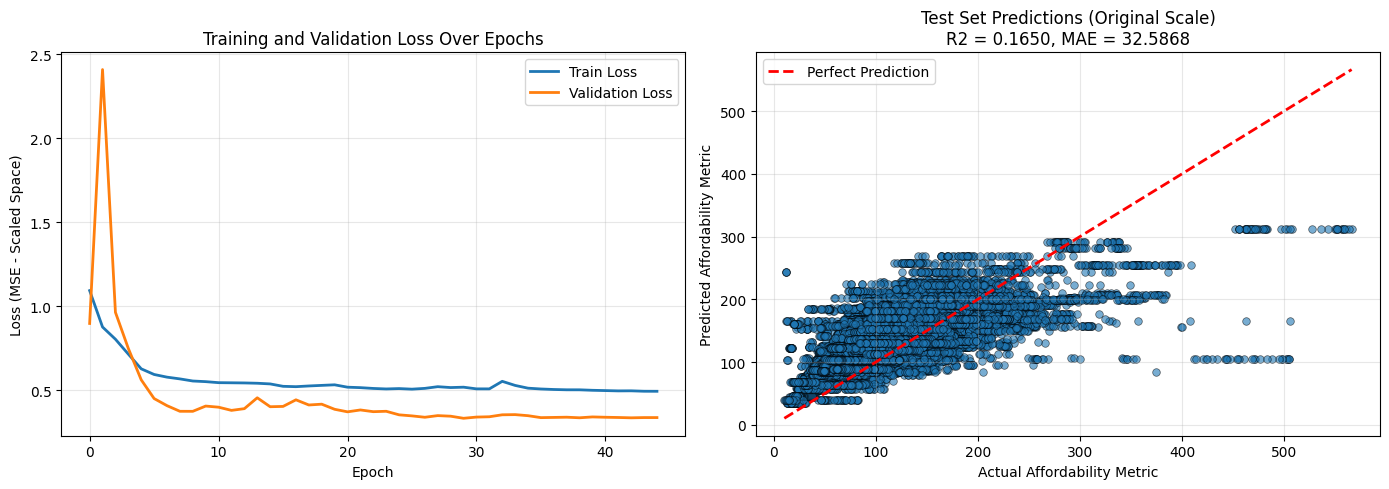

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE - Scaled Space)')
axes[0].set_title('Training and Validation Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# plot in original scale with metrics
axes[1].scatter(y_test_original, y_test_pred_original, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
min_val = min(y_test_original.min(), y_test_pred_original.min())
max_val = max(y_test_original.max(), y_test_pred_original.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Affordability Metric')
axes[1].set_ylabel('Predicted Affordability Metric')
axes[1].set_title(f'Test Set Predictions (Original Scale)\nR2 = {test_r2:.4f}, MAE = {test_mae:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
